# 18. Entity Resolution — Customer Deduplication

## Business Case

A bank may have customer records across many systems:

```text
Core Banking
Credit Card
Mobile Banking
CRM
Branch System
```

The same customer can appear multiple times because of different spelling, phone formatting, email formatting, address variations, missing values, and typos.

**Objective:** determine which records refer to the same real-world customer and create a trusted **Golden Customer ID**.

## 1. Why Customer Deduplication Matters

Duplicate customer records can cause:

- inflated customer counts,
- duplicate marketing campaigns,
- fragmented financial exposure,
- incomplete Customer 360,
- inconsistent risk analytics,
- poor customer experience.

The target architecture is:

```text
Raw Records → Entity Resolution → Golden Customer → Customer 360
```

## 2. Entity Resolution vs Exact Deduplication

`drop_duplicates()` only catches records that are exactly identical.

Entity Resolution handles:

```text
Exact Match
+ Fuzzy Match
+ Business Rules
+ Multiple Attributes
+ Confidence Score
```

Example:

```text
ANDI SANTOSO
08123456789

Andi Santoso
+628123456789
```

These may be the same real-world customer.

## 3. End-to-End Architecture

```text
Source Systems
      ↓
Standardization
      ↓
Exact Matching
      ↓
Candidate Blocking
      ↓
Fuzzy Matching
      ↓
Weighted Match Score
      ↓
Confidence Threshold
      ↓
Auto Match / Manual Review / Non-Match
      ↓
Golden Customer ID
      ↓
Customer 360
      ↓
Quality Monitoring
```

## 4. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, difflib for fuzzy string similarity, re for normalisation and itertools for pair generation.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

master=pd.read_csv("bank_customer_master.csv",parse_dates=["Date_of_Birth"])
source=pd.read_csv("bank_customer_source_records.csv",parse_dates=["Date_of_Birth"])

print("Master customers:",len(master))
print("Source records:",len(source))

display(master.head())
display(source.head())
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


Master customers: 1800
Source records: 3900


,Customer_ID,Full_Name,Date_of_Birth,Phone,Email,Address,City
0,C000001,Budi Siregar,2001-05-10,8719876990,customer000001@example.com,Jl. Gatot Subroto No. 132,Tangerang
1,C000002,Nanda Nugroho,2005-11-16,8705925651,customer000002@example.com,Jl. Merdeka No. 98,Medan
2,C000003,Iwan Ramadhan,1993-05-31,8579466383,customer000003@example.com,Jl. Gatot Subroto No. 56,Depok
3,C000004,Budi Kurniawan,2006-03-28,8122301019,customer000004@example.com,Jl. Gatot Subroto No. 84,Makassar
4,C000005,Eko Wijaya,2014-06-26,8449077622,customer000005@example.com,Jl. Sudirman No. 71,Semarang


,Source_System,Source_Record_ID,Full_Name,Date_of_Birth,Phone,Email,Address,City
0,Core Banking,CO_0000001,Vina Nugroho,1990-06-27,8784919414,customer000729@example.com,Jl. Merdeka No. 77,Bekasi
1,Core Banking,CO_0000002,BUDI SETIAWAN,2011-06-14,8750074170,customer001706@example.com,JL. GATOT SUBROTO NO. 52,Semarang
2,Core Banking,CO_0000003,Maya Pratama,2002-12-18,8346204317,customer001197@example.com,Jl. Diponegoro No. 12,Semarang
3,Core Banking,CO_0000004,1wanWijaya,2016-04-28,8893667427,customer001685@example.com,Jl. Ahmad Yani No. 59,Makassar
4,Core Banking,CO_0000005,RINA SETIAWAN,2001-06-09,8201444022,customer000544@example.com,JL. AHMAD YANI NO. 136,Bekasi


## 5. Dataset Dictionary

Customer records from multiple source systems are documented — name, date of birth, phone, email, address and national ID. Knowing which fields identify a person determines the blocking and matching strategy.


In [2]:
dictionary=pd.DataFrame({
    "Field":["Customer_ID","Source_System","Source_Record_ID","Full_Name","Date_of_Birth","Phone","Email","Address","City"],
    "Description":[
        "Golden customer identifier","Originating system","Source record identifier",
        "Customer name","Date of birth","Phone number","Email address",
        "Customer address","City"
    ]
})
display(dictionary)

,Field,Description
0,Customer_ID,Golden customer identifier
1,Source_System,Originating system
2,Source_Record_ID,Source record identifier
3,Full_Name,Customer name
4,Date_of_Birth,Date of birth
5,Phone,Phone number
6,Email,Email address
7,Address,Customer address
8,City,City


## 6. Data Quality Assessment

Missing values and format inconsistencies across source systems are assessed, because dirty identifiers are precisely what creates duplicate customer records.


In [3]:
print("Missing values:")
display(source.isna().sum().to_frame("Missing"))

print("Exact duplicate source rows:",source.duplicated().sum())

print("Records by source system:")
display(source["Source_System"].value_counts().to_frame("Records"))

Missing values:


,Missing
Source_System,0
Source_Record_ID,0
Full_Name,0
Date_of_Birth,0
Phone,0
Email,0
Address,0
City,0


Exact duplicate source rows: 0
Records by source system:


,Records
Source_System,
Credit Card,786
Mobile Banking,783
Core Banking,782
Branch System,778
CRM,771


## 7. Data Standardization

Typical transformations:

- Name → uppercase, remove punctuation, normalize spaces
- Phone → remove symbols and normalize `+62`, `62`, `08`
- Email → lowercase and remove accidental spaces
- Address → normalize common abbreviations

Standardization should happen **before** matching.

In [4]:
def normalize_text(x):
    if pd.isna(x): return ""
    x=str(x).upper()
    x=re.sub(r"[^A-Z0-9 ]"," ",x)
    return re.sub(r"\s+"," ",x).strip()

def normalize_phone(x):
    if pd.isna(x): return ""
    x=re.sub(r"\D","",str(x))
    if x.startswith("62"): x="0"+x[2:]
    return x

def normalize_email(x):
    if pd.isna(x): return ""
    return re.sub(r"\s+","",str(x).lower())

def normalize_address(x):
    x=normalize_text(x)
    return x.replace("JALAN","JL")

for d in [master,source]:
    d["Name_Norm"]=d["Full_Name"].apply(normalize_text)
    d["Phone_Norm"]=d["Phone"].apply(normalize_phone)
    d["Email_Norm"]=d["Email"].apply(normalize_email)
    d["Address_Norm"]=d["Address"].apply(normalize_address)
    d["Birth_Year"]=d["Date_of_Birth"].dt.year

display(source[["Full_Name","Name_Norm","Phone","Phone_Norm","Email","Email_Norm"]].head(10))

,Full_Name,Name_Norm,Phone,Phone_Norm,Email,Email_Norm
0,Vina Nugroho,VINA NUGROHO,8784919414,8784919414,customer000729@example.com,customer000729@example.com
1,BUDI SETIAWAN,BUDI SETIAWAN,8750074170,8750074170,customer001706@example.com,customer001706@example.com
2,Maya Pratama,MAYA PRATAMA,8346204317,8346204317,customer001197@example.com,customer001197@example.com
3,1wanWijaya,1WANWIJAYA,8893667427,8893667427,customer001685@example.com,customer001685@example.com
4,RINA SETIAWAN,RINA SETIAWAN,8201444022,8201444022,customer000544@example.com,customer000544@example.com
5,RinaRamadhan,RINARAMADHAN,8608601450,8608601450,customer000829@example.com,customer000829@example.com
6,Gita Nugroho,GITA NUGROHO,8217761808,8217761808,customer000400@example.com,customer000400@example.com
7,Hana Pratama,HANA PRATAMA,8383152069,8383152069,customer000587@example.com,customer000587@example.com
8,Karin Ramadhan,KARIN RAMADHAN,844555663,844555663,customer000334@example.com,customer000334@example.com
9,Maya Lestari,MAYA LESTARI,628608429944,08608429944,customer001092@example.com,customer001092@example.com


## 8. Exact Matching

Strong identifiers can be used first:

```text
Email exact
OR
Phone exact
OR
Name + Date of Birth exact
```

Exact matching is fast and provides high-confidence candidates before fuzzy matching.

In [5]:
email_lookup=master.groupby("Email_Norm").indices
phone_lookup=master.groupby("Phone_Norm").indices
name_dob_lookup=master.groupby(["Name_Norm","Date_of_Birth"]).indices

def exact_candidates(row):
    candidates=set()
    if row["Email_Norm"] in email_lookup:
        candidates.update(email_lookup[row["Email_Norm"]])
    if row["Phone_Norm"] in phone_lookup:
        candidates.update(phone_lookup[row["Phone_Norm"]])
    key=(row["Name_Norm"],row["Date_of_Birth"])
    if key in name_dob_lookup:
        candidates.update(name_dob_lookup[key])
    return list(candidates)

source["Exact_Candidates"]=source.apply(exact_candidates,axis=1)
source["Exact_Match_Count"]=source["Exact_Candidates"].str.len()

display(source["Exact_Match_Count"].value_counts().sort_index().to_frame("Records"))

,Records
Exact_Match_Count,
0,464
1,3436


## 9. Candidate Generation / Blocking

Full pairwise comparison requires:

```text
Number of source records × number of master records
```

For large banks this is expensive.

**Blocking** narrows candidates using fields such as:

- city,
- birth year,
- phone suffix,
- postal code,
- name initial.

Here we use:

```text
City + Birth Year
```

In [6]:
block_lookup={
    key:group.index.tolist()
    for key,group in master.groupby(["City","Birth_Year"])
}
print("Number of blocks:",len(block_lookup))

Number of blocks: 279


## 10. String Similarity

A fuzzy string-similarity function is defined so names and addresses that are not identical but clearly the same (typos, abbreviations, reordered words) can still be matched.


In [7]:
def similarity(a,b):
    return SequenceMatcher(None,str(a),str(b)).ratio()

def compare_records(s,m):
    return {
        "Name_Similarity":similarity(s["Name_Norm"],m["Name_Norm"]),
        "Phone_Similarity":similarity(s["Phone_Norm"],m["Phone_Norm"]),
        "Email_Similarity":similarity(s["Email_Norm"],m["Email_Norm"]),
        "Address_Similarity":similarity(s["Address_Norm"],m["Address_Norm"]),
        "DOB_Match":int(s["Date_of_Birth"]==m["Date_of_Birth"])
    }

## 11. Weighted Match Score

Illustrative weights:

```text
Email       30%
Phone       25%
Name        25%
DOB         15%
Address      5%
```

```text
Score =
0.30 Email Similarity
+ 0.25 Phone Similarity
+ 0.25 Name Similarity
+ 0.15 DOB Match
+ 0.05 Address Similarity
```

In production, weights and thresholds should be calibrated using labeled match / non-match data.

In [8]:
WEIGHTS={"Email":.30,"Phone":.25,"Name":.25,"DOB":.15,"Address":.05}

def match_score(f):
    return (
        WEIGHTS["Email"]*f["Email_Similarity"]
        +WEIGHTS["Phone"]*f["Phone_Similarity"]
        +WEIGHTS["Name"]*f["Name_Similarity"]
        +WEIGHTS["DOB"]*f["DOB_Match"]
        +WEIGHTS["Address"]*f["Address_Similarity"]
    )

## 12. Candidate Matching

For each source record:

1. Find candidates in the same block.
2. Compare multiple attributes.
3. Calculate a weighted score.
4. Select the highest scoring candidate.

This is a simplified educational implementation.

In [9]:
matches=[]

for sidx,srow in source.iterrows():
    candidates=block_lookup.get((srow["City"],srow["Birth_Year"]),[])
    best=None

    for midx in candidates:
        mrow=master.loc[midx]
        features=compare_records(srow,mrow)
        score=match_score(features)

        item={
            "Source_Index":sidx,
            "Master_Index":midx,
            "Customer_ID":mrow["Customer_ID"],
            "Score":score,
            **features
        }

        if best is None or score>best["Score"]:
            best=item

    if best is not None:
        matches.append(best)

matches=pd.DataFrame(matches)
display(matches.head())

,Source_Index,Master_Index,Customer_ID,Score,Name_Similarity,Phone_Similarity,Email_Similarity,Address_Similarity,DOB_Match
0,0,728,C000729,1.000000,1.000000,1.0,1.0,1.0,1
1,1,1705,C001706,1.000000,1.000000,1.0,1.0,1.0,1
2,2,1196,C001197,1.000000,1.000000,1.0,1.0,1.0,1
3,3,1684,C001685,0.964286,0.857143,1.0,1.0,1.0,1
4,4,543,C000544,1.000000,1.000000,1.0,1.0,1.0,1


## 13. Confidence Thresholds

Illustrative policy:

```text
Score ≥ 0.85
→ Auto Match

0.70 ≤ Score < 0.85
→ Manual Review

Score < 0.70
→ Non-Match
```

Do not force uncertain records into a customer.

In banking, an incorrect merge can contaminate financial exposure and customer information.

In [10]:
def classify_match(score):
    if score>=.85: return "Auto Match"
    if score>=.70: return "Manual Review"
    return "Non-Match"

matches["Decision"]=matches["Score"].apply(classify_match)

display(matches["Decision"].value_counts().to_frame("Records"))

,Records
Decision,
Auto Match,3500
Non-Match,399


## 14. Match Score Distribution

The distribution of match scores is plotted to find a natural cut-off between pairs that are the same person and pairs that merely look similar — the threshold decision this notebook makes explicit.


Saved: output/14-match-score-distribution.png


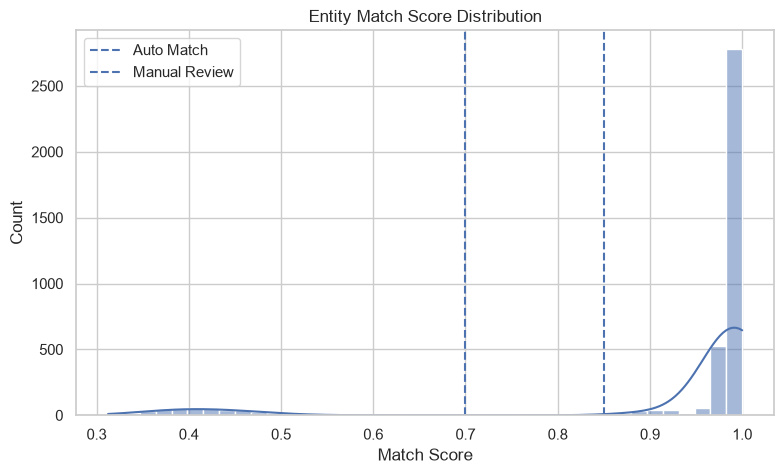

In [11]:
plt.figure(figsize=(9,5))
sns.histplot(matches["Score"],bins=40,kde=True)
plt.axvline(.85,ls="--",label="Auto Match")
plt.axvline(.70,ls="--",label="Manual Review")
plt.title("Entity Match Score Distribution")
plt.xlabel("Match Score")
plt.legend()
save_plot("14-match-score-distribution.png")
plt.show()

## 15. Create Golden Customer Mapping

Record pairs scoring above the threshold are linked to a single golden customer ID. This mapping is what collapses duplicate records into one customer view downstream systems can rely on.


In [12]:
result=source.copy()
result["Match_Customer_ID"]=None
result["Match_Score"]=0.0
result["Match_Decision"]="Non-Match"

for _,m in matches.iterrows():
    i=int(m["Source_Index"])
    result.loc[i,"Match_Customer_ID"]=m["Customer_ID"]
    result.loc[i,"Match_Score"]=m["Score"]
    result.loc[i,"Match_Decision"]=m["Decision"]

display(result[[
    "Source_System","Source_Record_ID","Full_Name",
    "Match_Customer_ID","Match_Score","Match_Decision"
]].head(20))

,Source_System,Source_Record_ID,Full_Name,Match_Customer_ID,Match_Score,Match_Decision
0,Core Banking,CO_0000001,Vina Nugroho,C000729,1.000000,Auto Match
1,Core Banking,CO_0000002,BUDI SETIAWAN,C001706,1.000000,Auto Match
2,Core Banking,CO_0000003,Maya Pratama,C001197,1.000000,Auto Match
3,Core Banking,CO_0000004,1wanWijaya,C001685,0.964286,Auto Match
4,Core Banking,CO_0000005,RINA SETIAWAN,C000544,1.000000,Auto Match
5,Core Banking,CO_0000006,RinaRamadhan,C000829,0.990000,Auto Match
6,Core Banking,CO_0000007,Gita Nugroho,C000400,1.000000,Auto Match
7,Core Banking,CO_0000008,Hana Pratama,C000587,1.000000,Auto Match
8,Core Banking,CO_0000009,Karin Ramadhan,C000334,0.986842,Auto Match
9,Core Banking,CO_0000010,Maya Lestari,C001092,0.988095,Auto Match


## 16. Deduplication KPIs

KPIs such as records in, unique customers out and duplication rate quantify how much duplication existed and how much cleaner the customer view is after resolution.


In [13]:
kpi=pd.DataFrame({
    "Metric":[
        "Source Records",
        "Auto Matches",
        "Manual Review",
        "Non-Matches",
        "Auto Match Rate"
    ],
    "Value":[
        len(result),
        (result["Match_Decision"]=="Auto Match").sum(),
        (result["Match_Decision"]=="Manual Review").sum(),
        (result["Match_Decision"]=="Non-Match").sum(),
        (result["Match_Decision"]=="Auto Match").mean()
    ]
})
display(kpi)

,Metric,Value
0,Source Records,3900.000000
1,Auto Matches,3500.000000
2,Manual Review,0.000000
3,Non-Matches,400.000000
4,Auto Match Rate,0.897436


## 17. Manual Review Queue

Medium-confidence records should be routed to human review.

The review queue should show:

- source record,
- candidate Golden Customer ID,
- individual similarity scores,
- overall score.

Human decisions can later become labeled training data for an ML matching model.

In [14]:
review_queue=matches[matches["Decision"]=="Manual Review"].copy()
display(review_queue[[
    "Source_Index","Customer_ID","Score",
    "Name_Similarity","Phone_Similarity",
    "Email_Similarity","DOB_Match","Address_Similarity"
]].head(30))

,Source_Index,Customer_ID,Score,Name_Similarity,Phone_Similarity,Email_Similarity,DOB_Match,Address_Similarity


## 18. Customer 360

After entity resolution, records can be aggregated by Golden Customer ID.

Example:

```text
C000123
 ├── Core Banking
 ├── Credit Card
 ├── Mobile Banking
 └── CRM
```

This creates a foundation for Customer 360 analytics.

In [15]:
customer_360=(
    result[result["Match_Decision"]=="Auto Match"]
    .groupby("Match_Customer_ID")
    .agg(
        Source_Record_Count=("Source_Record_ID","count"),
        Source_System_Count=("Source_System","nunique")
    )
    .reset_index()
)

display(customer_360.head(20))

,Match_Customer_ID,Source_Record_Count,Source_System_Count
0,C000001,1,1
1,C000003,2,2
2,C000004,4,4
3,C000005,2,2
4,C000006,1,1
5,C000007,1,1
6,C000008,1,1
7,C000009,1,1
8,C000010,1,1
9,C000011,2,2


## 19. False Positive vs False Negative

### False Positive

Different customers are incorrectly merged.

```text
A + B → One Customer
```

### False Negative

The same customer is incorrectly separated.

```text
A + A → Two Customers
```

For banking, both matter, but their business consequences may differ by use case.

## 20. Advanced Production Approaches

A production solution can use:

### Fuzzy matching

- RapidFuzz
- Levenshtein
- Jaro-Winkler

### Probabilistic matching

- Fellegi-Sunter
- likelihood ratios

### ML classifier

Features:

```text
name_similarity
phone_similarity
email_similarity
address_similarity
dob_match
city_match
```

Target:

```text
MATCH / NON-MATCH
```

### Graph-based resolution

Records become nodes and high-confidence links become edges. Connected components can represent real-world entities.

## 21. Golden Record Survivorship

Entity Resolution asks:

> Are these records the same customer?

Survivorship asks:

> Which attribute should become the trusted value?

Possible rules:

- trusted KYC source,
- most recently verified value,
- highest-quality source,
- majority value.

This is a separate but closely related MDM problem.

## 22. Production Architecture

```text
Core Banking ─┐
Credit Card ──┤
Mobile ───────┤
CRM ──────────┤
Branch ───────┘
       ↓
Standardization
       ↓
Exact Match
       ↓
Blocking
       ↓
Fuzzy / Probabilistic Match
       ↓
Confidence Decision
   ┌───┴────┐
 Auto     Review
 Match
   └───┬────┘
       ↓
Golden Customer
       ↓
Customer 360
       ↓
Monitoring
```

## 23. Monitoring

Monitor:

### Data Quality

- missing phone,
- missing email,
- malformed values,
- duplicate source IDs.

### Matching

- auto-match rate,
- review rate,
- non-match rate,
- score distribution.

### Drift

- new source systems,
- new formatting patterns,
- changes in identifiers.

### Business Impact

- duplicate reduction,
- Customer 360 coverage,
- consolidated exposure,
- campaign suppression.

## 24. Governance

Customer identity data is sensitive.

Production implementation should include:

- access control,
- encryption,
- audit trails,
- approved matching rules,
- manual review,
- reproducibility,
- clear Golden Record ownership.

Incorrect merges can combine financial exposure or customer information, so high-confidence matching must be carefully validated.

## 25. Common Mistakes

1. Exact matching only.
2. Matching only on name.
3. Ignoring phone normalization.
4. Ignoring email normalization.
5. Fuzzy matching without blocking.
6. Thresholds without labeled validation.
7. Automatically matching every record.
8. Ignoring false positives.
9. Ignoring false negatives.
10. No manual review process.
11. No survivorship rules.
12. No monitoring.
13. Treating entity resolution as a one-time cleanup.

## 26. Final Executive Summary

### Business Question

> **Which records across banking systems belong to the same real-world customer?**

### End-to-End

```text
Raw Customer Records
        ↓
Standardization
        ↓
Exact Matching
        ↓
Blocking
        ↓
Fuzzy Similarity
        ↓
Weighted Match Score
        ↓
Confidence Threshold
        ↓
Auto Match / Manual Review / Non-Match
        ↓
Golden Customer ID
        ↓
Customer 360
        ↓
Monitoring
```

### Key distinction

```text
Exact Deduplication
→ Are the records identical?

Entity Resolution
→ Do these records represent the same real-world entity?
```

Applications in banking include:

- Customer 360
- KYC
- fraud investigation
- AML analytics
- credit exposure consolidation
- marketing suppression
- cross-sell analytics
- risk aggregation
- regulatory reporting
- data quality management.

## 27. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [16]:
kpi.to_csv(OUTPUT_DIR / "deduplication_kpis.csv", index=False)
print("Saved:", OUTPUT_DIR / "deduplication_kpis.csv")
result.to_csv(OUTPUT_DIR / "golden_customer_mapping.csv", index=False)
print("Saved:", OUTPUT_DIR / "golden_customer_mapping.csv")
review_queue.to_csv(OUTPUT_DIR / "manual_review_queue.csv", index=False)
print("Saved:", OUTPUT_DIR / "manual_review_queue.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/deduplication_kpis.csv
Saved: output/golden_customer_mapping.csv
Saved: output/manual_review_queue.csv
  output/14-match-score-distribution.png
  output/deduplication_kpis.csv
  output/golden_customer_mapping.csv
  output/manual_review_queue.csv
